## import libraries

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine as p9
import geopandas as gpd
import kagglehub
from kagglehub import KaggleDatasetAdapter

pd.set_option('display.max_columns', None)


## import data from Kaggle

In [25]:
file_paths = ["WorldCupMatches.csv", "WorldCupPlayers.csv", "WorldCups.csv"]
df_list = []
for i in file_paths:
# Set the path to the file you'd like to load
    file_path = i

    # Load the latest version
    df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "abecklas/fifa-world-cup",
    file_path,
    # Provide any additional arguments like 
    # sql_query or pandas_kwargs. See the 
    # documenation for more information:
    # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
    )
    df_list.append(df)

matches_df = df_list[0]
players_df = df_list[1]
cups_df = df_list[2]



/var/folders/60/m3wm021x08vbp7kk3s0t94c40000gn/T/ipykernel_35776/2292670398.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.


In [26]:
print("First 5 records:", cups_df.head())

First 5 records:    Year      Country      Winner      Runners-Up    Third      Fourth  \
0  1930      Uruguay     Uruguay       Argentina      USA  Yugoslavia   
1  1934        Italy       Italy  Czechoslovakia  Germany     Austria   
2  1938       France       Italy         Hungary   Brazil      Sweden   
3  1950       Brazil     Uruguay          Brazil   Sweden       Spain   
4  1954  Switzerland  Germany FR         Hungary  Austria     Uruguay   

   GoalsScored  QualifiedTeams  MatchesPlayed Attendance  
0           70              13             18    590.549  
1           70              16             17    363.000  
2           84              15             18    375.700  
3           88              13             22  1.045.246  
4          140              16             26    768.607  


In [27]:
print(f'cups_df.columns: {cups_df.columns}')    
print(f'matches_df.columns: {matches_df.columns}')
print(f'players_df.columns: {players_df.columns}')

cups_df.columns: Index(['Year', 'Country', 'Winner', 'Runners-Up', 'Third', 'Fourth',
       'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance'],
      dtype='str')
matches_df.columns: Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials'],
      dtype='str')
players_df.columns: Index(['RoundID', 'MatchID', 'Team Initials', 'Coach Name', 'Line-up',
       'Shirt Number', 'Player Name', 'Position', 'Event'],
      dtype='str')


In [28]:
matches_df['Win conditions'].unique()

C = dict(
    gold='#FFD700', red='#FF6B6B', teal='#4ECDC4', purple='#A29BFE',
    green='#55EFC4', orange='#FFA07A', blue='#74B9FF', pink='#FD79A8',
    dark='#2D3436', gray='#636E72'
)

/var/folders/60/m3wm021x08vbp7kk3s0t94c40000gn/T/ipykernel_35776/1584096420.py:45: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
/Users/coraalbers/anaconda3/envs/capstone/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.


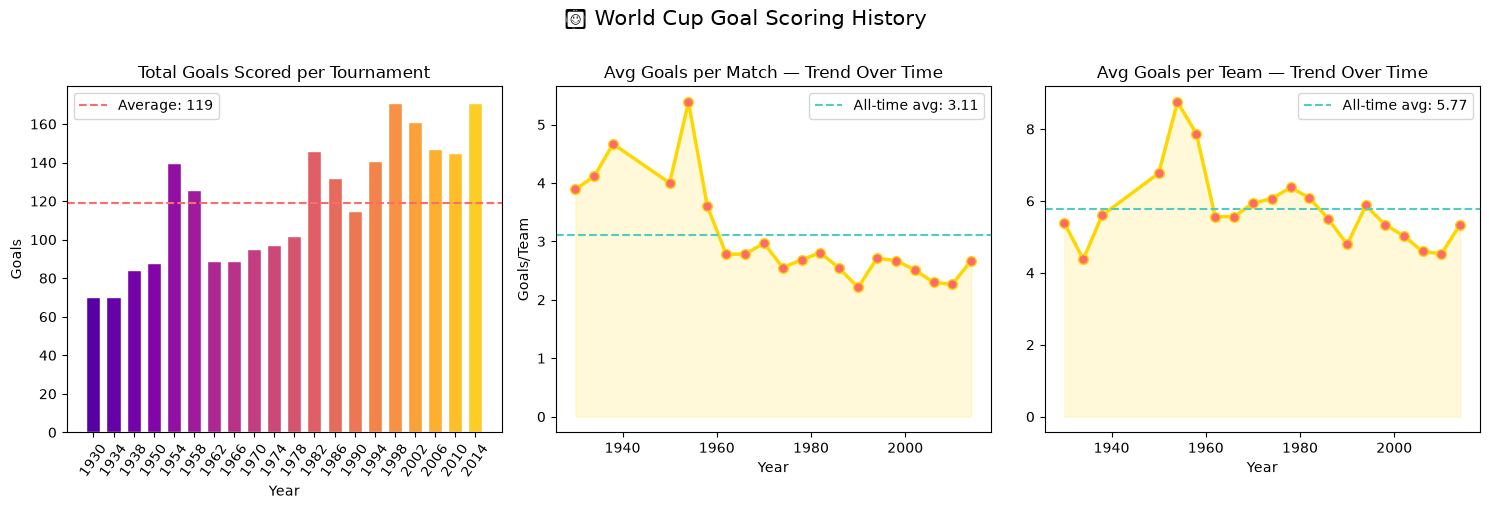

In [ ]:
# Goals scored & avg per match over time
# if GOALS_C and MATCH_C and YEAR_C:
cups_df['GoalsScored']  = pd.to_numeric(cups_df['GoalsScored'],  errors='coerce')
cups_df['MatchesPlayed']  = pd.to_numeric(cups_df['MatchesPlayed'],  errors='coerce')
cups_df['avg_goals_per_match'] = cups_df['GoalsScored'] / cups_df['MatchesPlayed']
cups_df['QualifiedTeams']  = pd.to_numeric(cups_df['QualifiedTeams'],  errors='coerce')
cups_df['avg_goals_per_team'] = cups_df['GoalsScored'] / cups_df['QualifiedTeams']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Total goals
colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(cups_df)))
bars = axes[0].bar(cups_df['Year'].astype(str), cups_df['GoalsScored'],
                    color=colors, edgecolor='white', width=0.7)
axes[0].set_title('Total Goals Scored per Tournament')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Goals')
axes[0].tick_params(axis='x', rotation=55)
axes[0].axhline(cups_df['GoalsScored'].mean(), color=C['red'], ls='--', lw=1.5,
                label=f'Average: {cups_df['GoalsScored'].mean():.0f}')
axes[0].legend()

# Avg goals per match
axes[1].plot(cups_df['Year'], cups_df['avg_goals_per_match'],
                color=C['gold'], lw=2.5, marker='o', markersize=7, markerfacecolor=C['red'])
axes[1].fill_between(cups_df['Year'], cups_df['avg_goals_per_match'],
                        alpha=0.15, color=C['gold'])
axes[1].set_title('Avg Goals per Match — Trend Over Time')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Goals/Match')
axes[1].axhline(cups_df['avg_goals_per_match'].mean(), color=C['teal'],
                ls='--', lw=1.5, label=f'All-time avg: {cups_df["avg_goals_per_match"].mean():.2f}')
axes[1].legend()

# Avg goals per team
axes[2].plot(cups_df['Year'], cups_df['avg_goals_per_team'],
                color=C['gold'], lw=2.5, marker='o', markersize=7, markerfacecolor=C['red'])
axes[2].fill_between(cups_df['Year'], cups_df['avg_goals_per_team'],
                        alpha=0.15, color=C['gold'])
axes[2].set_title('Avg Goals per Team — Trend Over Time')
axes[2].set_xlabel('Year'); axes[1].set_ylabel('Goals/Team')
axes[2].axhline(cups_df['avg_goals_per_team'].mean(), color=C['teal'],
                ls='--', lw=1.5, label=f'All-time avg: {cups_df["avg_goals_per_team"].mean():.2f}')
axes[2].legend()

plt.suptitle('World Cup Goal Scoring History', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

In [64]:
avg_points_per_year = pd.DataFrame(columns=['Team', 'AvgGoals', 'NumMatches', 'TotalGoals', 'Year'])

for i in range(len(matches_df['Year'].unique())):
    year = matches_df['Year'].unique()[i]
    print(year)
    year_df = matches_df[matches_df['Year'] == year]
    teams1 = list(year_df['Home Team Name'].unique())
    teams2 = list(year_df['Away Team Name'].unique())
    teams = teams1 + teams2
    teams = list(set(teams))
    # print(teams)

    data = {}

    # average goals per match per team based on number of matches played
    for i, row in year_df.iterrows():
        home_team = row['Home Team Name']
        away_team = row['Away Team Name']
        home_goals = row['Home Team Goals']
        away_goals = row['Away Team Goals']
        
        for i in teams:
            key = i
            # print(key)
            if home_team == key and key in data:
                data[key].append(home_goals)
            elif away_team == key and key in data:
                data[key].append(away_goals)
            elif home_team == key and key not in data:
                data[key] = [home_goals]
            elif away_team == key and key not in data:
                data[key] = [away_goals]

        
        # print(f"Team1: {home_team}, Team2: {away_team}, Goals1: {home_goals}, Goals2: {away_goals}")
    # print(data)

    for team, points in data.items():
        avg_goals = sum(points) / len(points)
        total_goals = sum(points)
        num_matches = len(points)
        print(f"Team: {team}, Avg Goals: {avg_goals}")
        avg_points_per_year.loc[len(avg_points_per_year)] = [team, avg_goals, num_matches, total_goals, year]


1930.0
Team: Mexico, Avg Goals: 1.3333333333333333
Team: France, Avg Goals: 1.3333333333333333
Team: USA, Avg Goals: 2.3333333333333335
Team: Belgium, Avg Goals: 0.0
Team: Brazil, Avg Goals: 2.5
Team: Yugoslavia, Avg Goals: 2.3333333333333335
Team: Peru, Avg Goals: 0.5
Team: Romania, Avg Goals: 1.5
Team: Argentina, Avg Goals: 3.6
Team: Chile, Avg Goals: 1.6666666666666667
Team: Bolivia, Avg Goals: 0.0
Team: Paraguay, Avg Goals: 0.5
Team: Uruguay, Avg Goals: 3.75
1934.0
Team: Austria, Avg Goals: 1.75
Team: France, Avg Goals: 2.0
Team: Hungary, Avg Goals: 2.5
Team: Egypt, Avg Goals: 2.0
Team: Switzerland, Avg Goals: 2.5
Team: Netherlands, Avg Goals: 2.0
Team: Argentina, Avg Goals: 2.0
Team: Sweden, Avg Goals: 2.0
Team: Belgium, Avg Goals: 2.0
Team: Germany, Avg Goals: 2.75
Team: Spain, Avg Goals: 1.3333333333333333
Team: Brazil, Avg Goals: 1.0
Team: USA, Avg Goals: 1.0
Team: Italy, Avg Goals: 2.4
Team: Czechoslovakia, Avg Goals: 2.25
Team: Romania, Avg Goals: 1.0
1938.0
Team: Switzerland

In [65]:
avg_points_per_year


,Team,AvgGoals,NumMatches,TotalGoals,Year
0,Mexico,1.333333,3,4.0,1930.0
1,France,1.333333,3,4.0,1930.0
2,USA,2.333333,3,7.0,1930.0
3,Belgium,0.000000,2,0.0,1930.0
4,Brazil,2.500000,2,5.0,1930.0
...,...,...,...,...,...
422,Ghana,1.333333,3,4.0,2014.0
423,Algeria,1.600000,5,8.0,2014.0
424,Belgium,1.142857,7,8.0,2014.0
425,Russia,0.666667,3,2.0,2014.0


<Axes: xlabel='Year', ylabel='AvgGoals'>

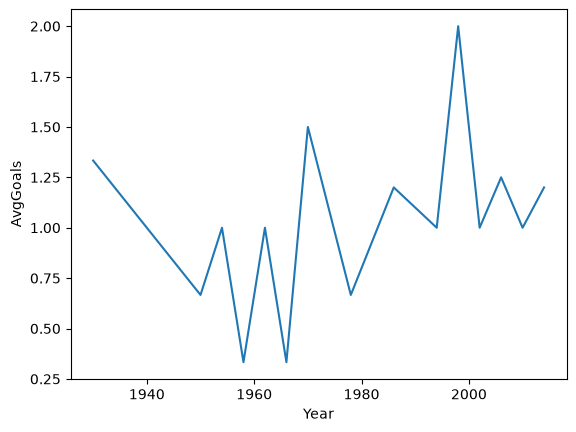

In [70]:
sns.lineplot(x='Year', y='AvgGoals', data=avg_points_per_year[avg_points_per_year['Team'] == 'Mexico'])